
Defining a 2D coordinate system related to Cartesian components x1, x2, respectively:


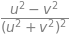

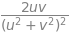

After checking the orthonormal basis conditions that the unit vector dot product is 0 and each unit vector has magnitude 1, the statement that the two vectors form an orthonormal basis is:
True

r can be expressed entirely in terms of u, v, e_u and e_v as follows:


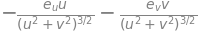


taking the time derivative of this expression yields:


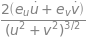

In [17]:
import sympy as smp
from sympy.vector import CoordSys3D
from sympy.physics.vector import dynamicsymbols, init_vprinting

init_vprinting()

class CoordinateMap2D:
    def __init__(self, x1_expr_str, x2_expr_str):
        self.C = CoordSys3D('C')
        self.t = smp.symbols('t')
        
        self.u = smp.symbols('u', positive=True, real=True)
        self.v = smp.symbols('v', positive=True, real=True)

        self.u_dyn = dynamicsymbols('u')
        self.v_dyn = dynamicsymbols('v')

        locals_dict = {'u': self.u, 'v': self.v}
        self.x1 = smp.sympify(x1_expr_str, locals=locals_dict)
        self.x2 = smp.sympify(x2_expr_str, locals=locals_dict)

        self.r_cartesian = self.x1 * self.C.i + self.x2 * self.C.j

    def magnitudes(self):
        dr_du_x1 = smp.diff(self.x1, self.u)
        dr_du_x2 = smp.diff(self.x2, self.u)
        
        u_factor = smp.factor(dr_du_x1**2 + dr_du_x2**2)
        u_mag = smp.powsimp(smp.sqrt(u_factor), force=True)

        dr_dv_x1 = smp.diff(self.x1, self.v)
        dr_dv_x2 = smp.diff(self.x2, self.v)
        
        v_factor = smp.factor(dr_dv_x1**2 + dr_dv_x2**2)
        v_mag = smp.powsimp(smp.sqrt(v_factor), force=True)

        return smp.simplify(u_mag), smp.simplify(v_mag)

    def e_u(self):
        dr_du_x1 = smp.diff(self.x1, self.u)
        dr_du_x2 = smp.diff(self.x2, self.u)
        return (dr_du_x1 / self.magnitudes()[0]) * self.C.i + (dr_du_x2 / self.magnitudes()[0]) * self.C.j

    def e_v(self):
        dr_dv_x1 = smp.diff(self.x1, self.v)
        dr_dv_x2 = smp.diff(self.x2, self.v)
        return (dr_dv_x1 / self.magnitudes()[1]) * self.C.i + (dr_dv_x2 / self.magnitudes()[1]) * self.C.j

    def check_orthonormal(self):
        e_u = self.e_u()
        e_v = self.e_v()
        dot_product = smp.simplify(e_u.dot(e_v))
        return dot_product == 0

    def position_vector(self):
        e_u = self.e_u()
        e_v = self.e_v()

        comp_u = smp.factor(smp.simplify(self.r_cartesian.dot(e_u)))
        comp_v = smp.factor(smp.simplify(self.r_cartesian.dot(e_v)))

        comp_u_dyn = comp_u.subs({self.u: self.u_dyn, self.v: self.v_dyn})
        comp_v_dyn = comp_v.subs({self.u: self.u_dyn, self.v: self.v_dyn})

        e_u_sym = smp.symbols('e_u')
        e_v_sym = smp.symbols('e_v')

        return comp_u_dyn * e_u_sym + comp_v_dyn * e_v_sym

    def velocity_vector(self):
    
        u_mag_dyn = self.magnitudes()[0].subs({self.u: self.u_dyn, self.v: self.v_dyn})
        v_mag_dyn = self.magnitudes()[1].subs({self.u: self.u_dyn, self.v: self.v_dyn})

        u_dot = smp.diff(self.u_dyn, self.t)
        v_dot = smp.diff(self.v_dyn, self.t)

        e_u_sym = smp.symbols('e_u')
        e_v_sym = smp.symbols('e_v')

        velocity = (u_mag_dyn * u_dot) * e_u_sym + (v_mag_dyn * v_dot) * e_v_sym
        return smp.factor(velocity)


#part a
uv = CoordinateMap2D('(u**2-v**2)/(u**2+v**2)**2', '2*u*v/(u**2+v**2)**2')
print('\nDefining a 2D coordinate system related to Cartesian components x1, x2, respectively:') 
display(uv.x1, uv.x2)
print('After checking the orthonormal basis conditions that the unit vector dot product is 0 and each unit vector has magnitude 1, the statement that the two vectors form an orthonormal basis is:')
print(uv.check_orthonormal())

#part b
print('\nr can be expressed entirely in terms of u, v, e_u and e_v as follows:')
display(uv.position_vector())

#part c
print('\ntaking the time derivative of this expression yields:')
display(uv.velocity_vector())
